In [ ]:
                                     import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
path = '/content/optimized_waste_management_data.csv'
df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.isnull().sum

,0
date,0
waste_volume,0
organic_waste,0
recyclable_waste,0
hazardous_waste,0
collection_frequency,0
landfill_capacity_used,0
recycling_rate,0


In [ ]:
df.head()

,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [ ]:
df = df.fillna(method='ffill')

/tmp/ipykernel_2804/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
waste_data = df[['waste_volume']]
waste_data.head()

,waste_volume
0,48.85
1,49.45
2,51.03
3,54.70
4,51.74


normalize the data
neural ntework work better when data values aare b/w 0 to 1




In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(waste_data)

convert data into sequences

In [ ]:
def create_sequences(data, seq_length):
  x=[]
  y=[]
  for i in range(len(data)-seq_length-1):
    x.append(data[i:(i+seq_length)])
    y.append(data[i+seq_length])
  return np.array(x),np.array(y)



create time sequence

In [ ]:
from typing import Sequence
Sequence_length = 10
x,y=create_sequences(scaled_data,Sequence_length)
print(x.shape)
print(y.shape)

(1450, 10, 1)
(1450, 1)


# Build the RNN Model

input------>RNN Layer----------->Dense output


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
model = Sequential()
model.add(SimpleRNN(50,activation='relu',return_sequences=True,input_shape=(Sequence_length,1)))
model.add(SimpleRNN(50,activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# compile the model

In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 10, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

# Train the model

In [ ]:
train_size = int(len(x) * 0.7)
X_train, X_test = x[0:train_size], x[train_size:len(x)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0066
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0066
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0067
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0070
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0067
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063
Epoc

In [ ]:
#prediction
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
#metrics
from sklearn.metrics import mean_squared_error
train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

Train RMSE: 0.05
Test RMSE: 0.13


In [ ]:
prediction_actual=scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform(y_test)

# plot predictions vs actual values

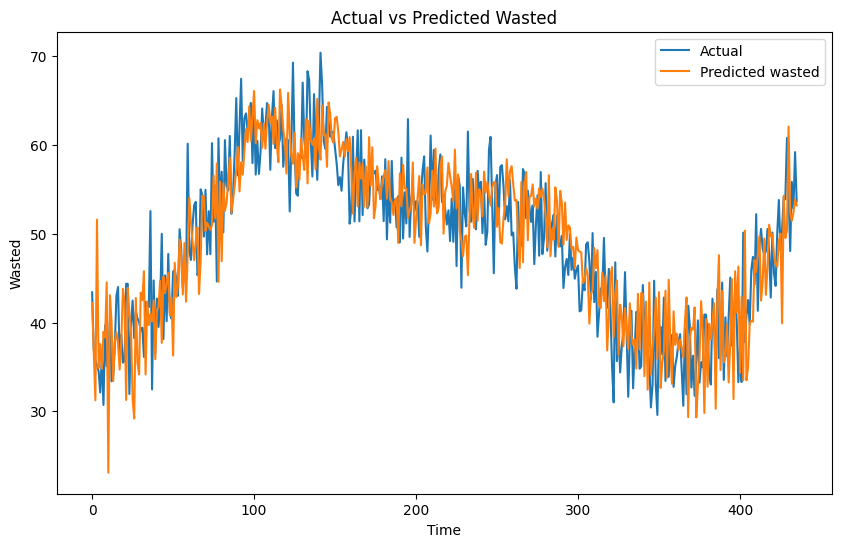

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label='Actual')
plt.plot(prediction_actual, label='Predicted wasted')
plt.title('Actual vs Predicted Wasted')
plt.xlabel('Time')
plt.ylabel('Wasted')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
path = '/content/IMDB_Dataset.csv'
df = pd.read_csv(path, engine='python', quotechar='"')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
# Count sentiments
sentiment_counts = df['sentiment'].value_counts()

print("\nSentiment Distribution:")
print(sentiment_counts)


Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


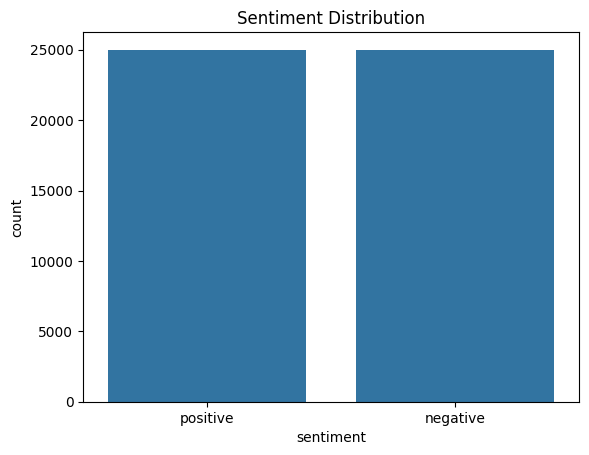

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✅ Dataset Loaded Successfully

📊 Dataset Shape: (50000, 2)

❌ Missing Values:
 review       0
sentiment    0
dtype: int64

📈 Sentiment Count:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


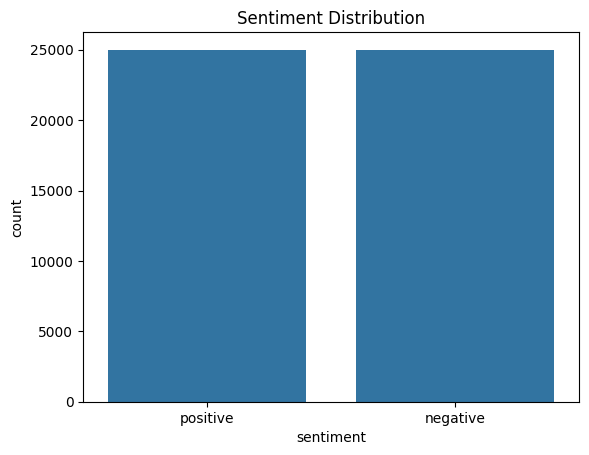


📝 Sample Positive Review:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

📝 Sample Negative Review:
 Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, J

📏 Review Length Stats:
 count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64

📌 Average Review Length: 231.15694


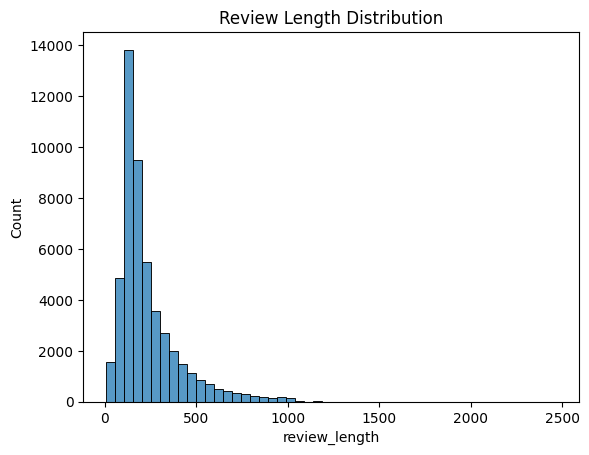


🧪 TEST CASE
Original: This movie was absolutely fantastic!
Processed: ['movie', 'absolutely', 'fantastic']

📚 Vocabulary Size: 222610

🔤 Word Index Sample:
<OOV> : 1
movie : 2
film : 3
one : 4
like : 5
good : 6
even : 7
would : 8
time : 9
really : 10

📦 Padded Shape: (50000, 200)

✔ Is dataset balanced?
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

✔ Are reviews long or short?
Average length: 231.15694
👉 Reviews are MODERATELY LONG

🧠 WHY NN CANNOT PROCESS RAW TEXT?

Neural networks work with numbers (vectors, matrices).
Text is unstructured (words, strings).

So we convert:
Text → Tokens → Numbers → Sequences

This allows neural networks to:
- Perform mathematical operations
- Learn patterns
- Optimize using gradients



In [ ]:
# ==============================
# 📦 IMPORTS
# ==============================
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# ==============================
# 🔹 TASK 2 — DATA EXPLORATION
# ==============================

# Load dataset
df = pd.read_csv('/content/IMDB_Dataset.csv')

print("✅ Dataset Loaded Successfully")

# 1. Dataset size
print("\n📊 Dataset Shape:", df.shape)

# 2. Missing values
print("\n❌ Missing Values:\n", df.isnull().sum())

# 3. Sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
print("\n📈 Sentiment Count:\n", sentiment_counts)

# Visualization
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# 4. Sample reviews
print("\n📝 Sample Positive Review:\n", df[df['sentiment']=='positive']['review'].iloc[0][:200])
print("\n📝 Sample Negative Review:\n", df[df['sentiment']=='negative']['review'].iloc[0][:200])

# 5. Review length
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print("\n📏 Review Length Stats:\n", df['review_length'].describe())

avg_len = df['review_length'].mean()
print("\n📌 Average Review Length:", avg_len)

# Plot
sns.histplot(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

# ==============================
# 🔹 TASK 3 — TEXT PREPROCESSING
# ==============================

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return tokens

# Apply preprocessing
df['processed_review'] = df['review'].apply(preprocess_text)

# ==============================
# 🔹 TEST CASE (VERY IMPORTANT)
# ==============================

test_sentence = "This movie was absolutely fantastic!"
processed_test = preprocess_text(test_sentence)

print("\n🧪 TEST CASE")
print("Original:", test_sentence)
print("Processed:", processed_test)

# Expected:
# ["movie", "absolutely", "fantastic"]

# ==============================
# 🔹 TASK 4 — TOKENIZATION
# ==============================

# Convert tokens back to string for tokenizer
df['clean_text'] = df['processed_review'].apply(lambda x: " ".join(x))

# Initialize tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

# Fit tokenizer
tokenizer.fit_on_texts(df['clean_text'])

# Convert text → sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Vocabulary
word_index = tokenizer.word_index

print("\n📚 Vocabulary Size:", len(word_index))

# Display first 10 words
print("\n🔤 Word Index Sample:")
for word, index in list(word_index.items())[:10]:
    print(word, ":", index)

# Padding (for DL models)
padded_sequences = pad_sequences(sequences, maxlen=200)

print("\n📦 Padded Shape:", padded_sequences.shape)

# ==============================
# 🔥 FINAL CHECKS
# ==============================

# Check balance
print("\n✔ Is dataset balanced?")
print(sentiment_counts)

# Check length nature
print("\n✔ Are reviews long or short?")
print("Average length:", avg_len)

if avg_len > 150:
    print("👉 Reviews are MODERATELY LONG")
else:
    print("👉 Reviews are SHORT")

# ==============================
# 🧠 THEORY ANSWER
# ==============================

print("\n🧠 WHY NN CANNOT PROCESS RAW TEXT?")
print("""
Neural networks work with numbers (vectors, matrices).
Text is unstructured (words, strings).

So we convert:
Text → Tokens → Numbers → Sequences

This allows neural networks to:
- Perform mathematical operations
- Learn patterns
- Optimize using gradients
""")

In [ ]:
# ==============================
# 🔹 TASK 5 — SEQUENCE PADDING
# ==============================

# 1. Find maximum review length (in sequences)
max_length = max(len(seq) for seq in sequences)

print("\n📏 Maximum Sequence Length:", max_length)

# Also check distribution
lengths = [len(seq) for seq in sequences]

print("\n📊 Length Stats:")
print("Min:", min(lengths))
print("Max:", max(lengths))
print("Average:", sum(lengths)/len(lengths))

# 2. Apply Padding
# We will choose a fixed length (e.g., 200 for efficiency)
MAX_LEN = 200

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='pre',   # add zeros at beginning
    truncating='pre' # cut from beginning if too long
)

print("\n✅ Padding Applied")
print("Padded Shape:", padded_sequences.shape)

# ==============================
# 🔹 BEFORE vs AFTER COMPARISON
# ==============================

print("\n🔍 BEFORE PADDING (first review):")
print(sequences[0][:20])  # first 20 tokens

print("\n🔍 AFTER PADDING (first review):")
print(padded_sequences[0][:20])  # first 20 after padding

# ==============================
# 🔹 TEST CASE (VERY IMPORTANT)
# ==============================

test_seq = [12, 45, 67]

print("\n🧪 TEST CASE")
print("Before Padding:", test_seq)

test_padded = pad_sequences([test_seq], maxlen=6, padding='pre')

print("After Padding:", test_padded[0])

# Expected:
# [0, 0, 0, 12, 45, 67]


📏 Maximum Sequence Length: 1429

📊 Length Stats:
Min: 3
Max: 1429
Average: 119.8557

✅ Padding Applied
Padded Shape: (50000, 200)

🔍 BEFORE PADDING (first review):
[4, 1810, 942, 57, 399, 3217, 287, 350, 3025, 108, 483, 472, 7413, 20, 58, 3098, 3217, 5385, 1, 51]

🔍 AFTER PADDING (first review):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

🧪 TEST CASE
Before Padding: [12, 45, 67]
After Padding: [ 0  0  0 12 45 67]



📦 Train Shape: (40000, 200)
📦 Test Shape: (10000, 200)

🧠 MODEL SUMMARY:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.7094 - loss: 0.5280 - val_accuracy: 0.8738 - val_loss: 0.3030
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8674 - loss: 0.3263 - val_accuracy: 0.8717 - val_loss: 0.3135
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9268 - loss: 0.1921 - val_accuracy: 0.8524 - val_loss: 0.3564
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9726 - loss: 0.0831 - val_accuracy: 0.8562 - val_loss: 0.4802
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9873 - loss: 0.0390 - val_accuracy: 0.8352 - val_loss: 0.6267


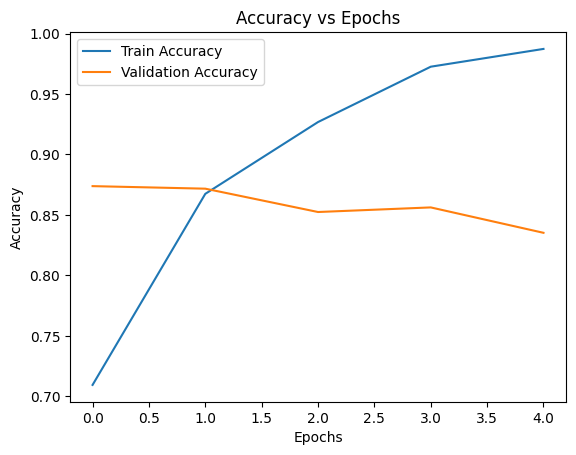


📊 FINAL TRAIN ACC: 0.9872750043869019
📊 FINAL VAL ACC: 0.8352000117301941


In [ ]:
# ==============================
# 🔹 IMPORTS (DL PART)
# ==============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==============================
# 🔹 PREPARE LABELS
# ==============================

# Convert sentiment to numeric
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

y = df['label'].values
X = padded_sequences

# ==============================
# 🔹 TRAIN-TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n📦 Train Shape:", X_train.shape)
print("📦 Test Shape:", X_test.shape)

# ==============================
# 🔹 TASK 6 — BUILD RNN MODEL
# ==============================

VOCAB_SIZE = 10000   # same as tokenizer
EMBEDDING_DIM = 128
MAX_LEN = 200

model = Sequential()

# 1. Embedding Layer
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))

# 2. SimpleRNN Layer
model.add(SimpleRNN(64))

# 3. Dense Layer
model.add(Dense(32, activation='relu'))

# 4. Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\n🧠 MODEL SUMMARY:")
model.summary()


history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test)
)


plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


print("\n📊 FINAL TRAIN ACC:", history.history['accuracy'][-1])
print("📊 FINAL VAL ACC:", history.history['val_accuracy'][-1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step

✅ Accuracy: 0.8352

📊 Confusion Matrix:
 [[4214  747]
 [ 901 4138]]


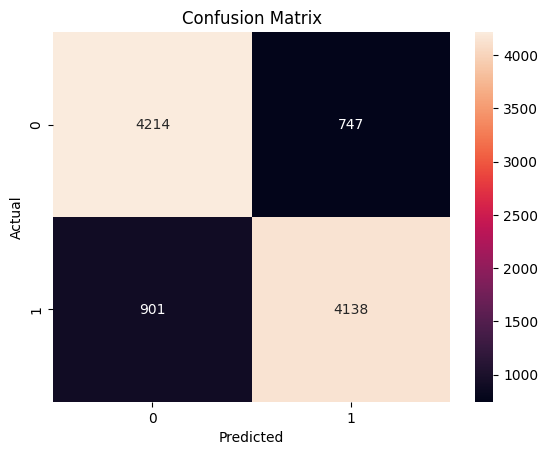


🎯 Precision: 0.8470829068577277
🔍 Recall: 0.8211946814844215

❌ Number of Misclassified Reviews: 1648

--- MISCLASSIFIED REVIEW ---
Actual: 1 Predicted: 0
Review: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

--- MISCLASSIFIED REVIEW ---
Actual: 1 Predicted: 0
Review: This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show was not really funny anymore, and it's continued its decline further to the complete waste of time it is today.<br /><br />It

--- MISCLASSIFIED REVIEW ---
Actual: 0 Predicted: 1
Review: Phil the Alien is one of those quirky films where the humour is based around the oddness of everything rather th

In [ ]:
# ==============================
# 🔹 TASK 8 — MODEL EVALUATION
# ==============================

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
import seaborn as sns
import numpy as np

# ==============================
# 🔹 PREDICTIONS
# ==============================

# Get predictions (probabilities)
y_pred_prob = model.predict(X_test)

# Convert to 0/1
y_pred = (y_pred_prob > 0.5).astype(int)

# ==============================
# 🔹 ACCURACY
# ==============================

accuracy = accuracy_score(y_test, y_pred)
print("\n✅ Accuracy:", accuracy)

# ==============================
# 🔹 CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test, y_pred)

print("\n📊 Confusion Matrix:\n", cm)

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# 🔹 PRECISION & RECALL
# ==============================

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n🎯 Precision:", precision)
print("🔍 Recall:", recall)

# ==============================
# 🔹 MISCLASSIFIED REVIEWS
# ==============================

misclassified_indices = np.where(y_test != y_pred.flatten())[0]

print("\n❌ Number of Misclassified Reviews:", len(misclassified_indices))

# Show few examples
for i in misclassified_indices[:3]:
    print("\n--- MISCLASSIFIED REVIEW ---")
    print("Actual:", y_test[i], "Predicted:", y_pred[i][0])
    print("Review:", df['review'].iloc[i][:300])

In [ ]:
# ==============================
# 🔹 TASK 9 — REAL-TIME PREDICTION
# ==============================

def predict_review(review_text):
    # 1. Preprocess (same as training)
    processed = preprocess_text(review_text)

    # Convert to string
    processed_text = " ".join(processed)

    # 2. Tokenize
    seq = tokenizer.texts_to_sequences([processed_text])

    # 3. Padding
    padded = pad_sequences(seq, maxlen=200, padding='pre')

    # 4. Prediction
    prob = model.predict(padded)[0][0]

    # 5. Convert to label
    if prob >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, prob

# ==============================
# 🔹 TEST WITH CUSTOM REVIEWS
# ==============================

test_reviews = [
    "This movie was absolutely fantastic and inspiring",
    "Worst film ever, complete waste of time",
    "The story was okay but acting was great",
    "I didn't like the movie, it was boring",
    "Amazing visuals but very slow storyline"
]

print("\n🧪 REAL-TIME PREDICTIONS\n")

for review in test_reviews:
    sentiment, confidence = predict_review(review)

    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("Confidence:", round(confidence, 2))
    print("-" * 50)



🧪 REAL-TIME PREDICTIONS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Review: This movie was absolutely fantastic and inspiring
Predicted Sentiment: Negative
Confidence: 0.38
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Review: Worst film ever, complete waste of time
Predicted Sentiment: Negative
Confidence: 0.0
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Review: The story was okay but acting was great
Predicted Sentiment: Positive
Confidence: 0.87
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Review: I didn't like the movie, it was boring
Predicted Sentiment: Negative
Confidence: 0.01
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Review: Amazing visuals but very slow storyline
Predicted Sentiment: Negative
Confidence: 0.18
--------------------------------------------------
